## **MAE**
https://github.com/facebookresearch/mae

##### 기타 필요 함수

In [1]:
import math

def adjust_learning_rate(optimizer, epoch, args):
    if epoch < args.warmup_epochs:
        lr = args.lr * epoch / args.warmup_epochs
    else:
        lr = args.min_lr + (args.lr - args.min_lr) * 0.5 * \
            (1. + math.cos(math.pi * (epoch - args.warmup_epochs) / (args.epochs - args.warmup_epochs)))
    for param_group in optimizer.param_groups:
        if "lr_scale" in param_group:
            param_group["lr"] = lr * param_group["lr_scale"]
        else:
            param_group["lr"] = lr
    return lr

In [2]:
import numpy as np
import torch

def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)
    grid = np.stack(grid, axis=0)
    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = np.concatenate([np.zeros([1, embed_dim], dtype=np.float32), pos_embed], axis=0)
    return pos_embed

def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])
    emb = np.concatenate([emb_h, emb_w], axis=1)
    return emb

def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=float)
    omega /= embed_dim / 2.
    omega = 1. / (10000 ** omega)
    pos = pos.reshape(-1)
    out = np.einsum('m,d->md', pos, omega)
    emb_sin = np.sin(out)
    emb_cos = np.cos(out)
    emb = np.concatenate([emb_sin, emb_cos], axis=1)
    return emb

def interpolate_pos_embed(model, checkpoint_model):
    if 'pos_embed' in checkpoint_model:
        pos_embed_checkpoint = checkpoint_model['pos_embed']
        embedding_size = pos_embed_checkpoint.shape[-1]
        num_patches = model.patch_embed.num_patches
        num_extra_tokens = model.pos_embed.shape[-2] - num_patches
        orig_size = int((pos_embed_checkpoint.shape[-2] - num_extra_tokens) ** 0.5)
        new_size = int(num_patches ** 0.5)
        if orig_size != new_size:
            print("Position interpolate from %dx%d to %dx%d" % (orig_size, orig_size, new_size, new_size))
            extra_tokens = pos_embed_checkpoint[:, :num_extra_tokens]
            pos_tokens = pos_embed_checkpoint[:, num_extra_tokens:]
            pos_tokens = pos_tokens.reshape(-1, orig_size, orig_size, embedding_size).permute(0, 3, 1, 2)
            pos_tokens = torch.nn.functional.interpolate(
                pos_tokens, size=(new_size, new_size), mode='bicubic', align_corners=False)
            pos_tokens = pos_tokens.permute(0, 2, 3, 1).flatten(1, 2)
            new_pos_embed = torch.cat((extra_tokens, pos_tokens), dim=1)
            checkpoint_model['pos_embed'] = new_pos_embed


In [3]:
import builtins
import datetime
import os
import time
from collections import defaultdict, deque
from pathlib import Path
import torch
import torch.distributed as dist


class SmoothedValue(object):
    def __init__(self, window_size=20, fmt=None):
        if fmt is None:
            fmt = "{median:.4f} ({global_avg:.4f})"
        self.deque = deque(maxlen=window_size)
        self.total = 0.0
        self.count = 0
        self.fmt = fmt

    def update(self, value, n=1):
        self.deque.append(value)
        self.count += n
        self.total += value * n

    def synchronize_between_processes(self):
        if not is_dist_avail_and_initialized():
            return
        t = torch.tensor([self.count, self.total], dtype=torch.float64, device='cuda')
        dist.barrier()
        dist.all_reduce(t)
        t = t.tolist()
        self.count = int(t[0])
        self.total = t[1]

    @property
    def median(self):
        d = torch.tensor(list(self.deque))
        return d.median().item()

    @property
    def avg(self):
        d = torch.tensor(list(self.deque), dtype=torch.float32)
        return d.mean().item()

    @property
    def global_avg(self):
        return self.total / self.count

    @property
    def max(self):
        return max(self.deque)

    @property
    def value(self):
        return self.deque[-1]

    def __str__(self):
        return self.fmt.format(
            median=self.median,
            avg=self.avg,
            global_avg=self.global_avg,
            max=self.max,
            value=self.value)


class MetricLogger(object):
    def __init__(self, delimiter="\t"):
        self.meters = defaultdict(SmoothedValue)
        self.delimiter = delimiter

    def update(self, **kwargs):
        for k, v in kwargs.items():
            if v is None:
                continue
            if isinstance(v, torch.Tensor):
                v = v.item()
            assert isinstance(v, (float, int))
            self.meters[k].update(v)

    def __getattr__(self, attr):
        if attr in self.meters:
            return self.meters[attr]
        if attr in self.__dict__:
            return self.__dict__[attr]
        raise AttributeError("'{}' object has no attribute '{}'".format(
            type(self).__name__, attr))

    def __str__(self):
        loss_str = []
        for name, meter in self.meters.items():
            loss_str.append(
                "{}: {}".format(name, str(meter))
            )
        return self.delimiter.join(loss_str)

    def synchronize_between_processes(self):
        for meter in self.meters.values():
            meter.synchronize_between_processes()

    def add_meter(self, name, meter):
        self.meters[name] = meter

    def log_every(self, iterable, print_freq, header=None):
        i = 0
        if not header:
            header = ''
        start_time = time.time()
        end = time.time()
        iter_time = SmoothedValue(fmt='{avg:.4f}')
        data_time = SmoothedValue(fmt='{avg:.4f}')
        space_fmt = ':' + str(len(str(len(iterable)))) + 'd'
        log_msg = [
            header,
            '[{0' + space_fmt + '}/{1}]',
            'eta: {eta}',
            '{meters}',
            'time: {time}',
            'data: {data}'
        ]
        if torch.cuda.is_available():
            log_msg.append('max mem: {memory:.0f}')
        log_msg = self.delimiter.join(log_msg)
        MB = 1024.0 * 1024.0
        for obj in iterable:
            data_time.update(time.time() - end)
            yield obj
            iter_time.update(time.time() - end)
            if i % print_freq == 0 or i == len(iterable) - 1:
                eta_seconds = iter_time.global_avg * (len(iterable) - i)
                eta_string = str(datetime.timedelta(seconds=int(eta_seconds)))
                if torch.cuda.is_available():
                    print(log_msg.format(
                        i, len(iterable), eta=eta_string,
                        meters=str(self),
                        time=str(iter_time), data=str(data_time),
                        memory=torch.cuda.max_memory_allocated() / MB))
                else:
                    print(log_msg.format(
                        i, len(iterable), eta=eta_string,
                        meters=str(self),
                        time=str(iter_time), data=str(data_time)))
            i += 1
            end = time.time()
        total_time = time.time() - start_time
        total_time_str = str(datetime.timedelta(seconds=int(total_time)))
        print('{} Total time: {} ({:.4f} s / it)'.format(
            header, total_time_str, total_time / len(iterable)))


def setup_for_distributed(is_master):
    builtin_print = builtins.print

    def print(*args, **kwargs):
        force = kwargs.pop('force', False)
        force = force or (get_world_size() > 8)
        if is_master or force:
            now = datetime.datetime.now().time()
            builtin_print('[{}] '.format(now), end='')
            builtin_print(*args, **kwargs)

    builtins.print = print


def is_dist_avail_and_initialized():
    if not dist.is_available():
        return False
    if not dist.is_initialized():
        return False
    return True


def get_world_size():
    if not is_dist_avail_and_initialized():
        return 1
    return dist.get_world_size()


def get_rank():
    if not is_dist_avail_and_initialized():
        return 0
    return dist.get_rank()


def is_main_process():
    return get_rank() == 0


def save_on_master(*args, **kwargs):
    if is_main_process():
        torch.save(*args, **kwargs)


def init_distributed_mode(args):
    if args.dist_on_itp:
        args.rank = int(os.environ['OMPI_COMM_WORLD_RANK'])
        args.world_size = int(os.environ['OMPI_COMM_WORLD_SIZE'])
        args.gpu = int(os.environ['OMPI_COMM_WORLD_LOCAL_RANK'])
        args.dist_url = "tcp://%s:%s" % (os.environ['MASTER_ADDR'], os.environ['MASTER_PORT'])
        os.environ['LOCAL_RANK'] = str(args.gpu)
        os.environ['RANK'] = str(args.rank)
        os.environ['WORLD_SIZE'] = str(args.world_size)
    elif 'RANK' in os.environ and 'WORLD_SIZE' in os.environ:
        args.rank = int(os.environ["RANK"])
        args.world_size = int(os.environ['WORLD_SIZE'])
        args.gpu = int(os.environ['LOCAL_RANK'])
    elif 'SLURM_PROCID' in os.environ:
        args.rank = int(os.environ['SLURM_PROCID'])
        args.gpu = args.rank % torch.cuda.device_count()
    else:
        print('Not using distributed mode')
        setup_for_distributed(is_master=True)
        args.distributed = False
        return

    args.distributed = True

    torch.cuda.set_device(args.gpu)
    args.dist_backend = 'nccl'
    print('| distributed init (rank {}): {}, gpu {}'.format(
        args.rank, args.dist_url, args.gpu), flush=True)
    torch.distributed.init_process_group(backend=args.dist_backend, init_method=args.dist_url,
                                         world_size=args.world_size, rank=args.rank)
    torch.distributed.barrier()
    setup_for_distributed(args.rank == 0)


class NativeScalerWithGradNormCount:
    state_dict_key = "amp_scaler"

    def __init__(self):
        self._scaler = torch.cuda.amp.GradScaler()

    def __call__(self, loss, optimizer, clip_grad=None, parameters=None, create_graph=False, update_grad=True):
        self._scaler.scale(loss).backward(create_graph=create_graph)
        if update_grad:
            if clip_grad is not None:
                assert parameters is not None
                self._scaler.unscale_(optimizer)
                norm = torch.nn.utils.clip_grad_norm_(parameters, clip_grad)
            else:
                self._scaler.unscale_(optimizer)
                norm = get_grad_norm_(parameters)
            self._scaler.step(optimizer)
            self._scaler.update()
        else:
            norm = None
        return norm

    def state_dict(self):
        return self._scaler.state_dict()

    def load_state_dict(self, state_dict):
        self._scaler.load_state_dict(state_dict)

def get_grad_norm_(parameters, norm_type: float = 2.0) -> torch.Tensor:
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    parameters = [p for p in parameters if p.grad is not None]
    norm_type = float(norm_type)
    if len(parameters) == 0:
        return torch.tensor(0.)
    device = parameters[0].grad.device
    if norm_type == float('inf'):
        total_norm = max(p.grad.detach().abs().max().to(device) for p in parameters)
    else:
        total_norm = torch.norm(torch.stack([torch.norm(p.grad.detach(), norm_type).to(device) for p in parameters]), norm_type)
    return total_norm

def save_model(args, epoch, model, model_without_ddp, optimizer, loss_scaler):
    output_dir = Path(args.output_dir)
    epoch_name = str(epoch)
    if loss_scaler is not None:
        checkpoint_paths = [output_dir / ('checkpoint-%s.pth' % epoch_name)]
        for checkpoint_path in checkpoint_paths:
            to_save = {
                'model': model_without_ddp.state_dict(),
                'optimizer': optimizer.state_dict(),
                'epoch': epoch,
                'scaler': loss_scaler.state_dict(),
                'args': args,
            }

            save_on_master(to_save, checkpoint_path)
    else:
        client_state = {'epoch': epoch}
        model.save_checkpoint(save_dir=args.output_dir, tag="checkpoint-%s" % epoch_name, client_state=client_state)


def load_model(args, model_without_ddp, optimizer, loss_scaler):
    if args.resume:
        if args.resume.startswith('https'):
            checkpoint = torch.hub.load_state_dict_from_url(
                args.resume, map_location='cpu', check_hash=True)
        else:
            checkpoint = torch.load(args.resume, map_location='cpu')
        model_without_ddp.load_state_dict(checkpoint['model'])
        print("Resume checkpoint %s" % args.resume)
        if 'optimizer' in checkpoint and 'epoch' in checkpoint and not (hasattr(args, 'eval') and args.eval):
            optimizer.load_state_dict(checkpoint['optimizer'])
            args.start_epoch = checkpoint['epoch'] + 1
            if 'scaler' in checkpoint:
                loss_scaler.load_state_dict(checkpoint['scaler'])
            print("With optim & sched!")


def all_reduce_mean(x):
    world_size = get_world_size()
    if world_size > 1:
        x_reduce = torch.tensor(x).cuda()
        dist.all_reduce(x_reduce)
        x_reduce /= world_size
        return x_reduce.item()
    else:
        return x

### *MAE 모델 구조 정의*
`models_mae.py`

In [4]:
from functools import partial
import torch
import torch.nn as nn
from timm.models.vision_transformer import PatchEmbed, Block

class MaskedAutoencoderViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 embed_dim=1024, depth=24, num_heads=16,
                 decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=16,
                 mlp_ratio=4., norm_layer=nn.LayerNorm, norm_pix_loss=False):
        super().__init__()

        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim), requires_grad=False)
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for i in range(depth)])
        self.norm = norm_layer(embed_dim)
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim), requires_grad=False)
        self.decoder_blocks = nn.ModuleList([
            Block(decoder_embed_dim, decoder_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for i in range(decoder_depth)])
        self.decoder_norm = norm_layer(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True)
        self.norm_pix_loss = norm_pix_loss
        self.initialize_weights()

    def initialize_weights(self):
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], int(self.patch_embed.num_patches**.5), cls_token=True)
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))
        decoder_pos_embed = get_2d_sincos_pos_embed(self.decoder_pos_embed.shape[-1], int(self.patch_embed.num_patches**.5), cls_token=True)
        self.decoder_pos_embed.data.copy_(torch.from_numpy(decoder_pos_embed).float().unsqueeze(0))
        w = self.patch_embed.proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))
        torch.nn.init.normal_(self.cls_token, std=.02)
        torch.nn.init.normal_(self.mask_token, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def patchify(self, imgs):
        p = self.patch_embed.patch_size[0]
        assert imgs.shape[2] == imgs.shape[3] and imgs.shape[2] % p == 0

        h = w = imgs.shape[2] // p
        x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * 3))
        return x

    def unpatchify(self, x):
        p = self.patch_embed.patch_size[0]
        h = w = int(x.shape[1]**.5)
        assert h * w == x.shape[1]
        x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], 3, h * p, h * p))
        return imgs

    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore

    def forward_encoder(self, x, mask_ratio):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        x, mask, ids_restore = self.random_masking(x, mask_ratio)

        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        return x, mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        x = torch.cat([x[:, :1, :], x_], dim=1)
        x = x + self.decoder_pos_embed

        for blk in self.decoder_blocks:
            x = blk(x)

        x = self.decoder_norm(x)
        x = self.decoder_pred(x)
        x = x[:, 1:, :]

        return x

    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**.5

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss

    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask


# 모델 생성 함수들
def mae_vit_base_patch16_dec512d8b(**kwargs):
    model = MaskedAutoencoderViT(
        patch_size=16, embed_dim=768, depth=12, num_heads=12,
        decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=16,
        mlp_ratio=4, norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
    return model

def mae_vit_large_patch16_dec512d8b(**kwargs):
    model = MaskedAutoencoderViT(
        patch_size=16, embed_dim=1024, depth=24, num_heads=16,
        decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=16,
        mlp_ratio=4, norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
    return model

def mae_vit_huge_patch14_dec512d8b(**kwargs):
    model = MaskedAutoencoderViT(
        patch_size=14, embed_dim=1280, depth=32, num_heads=16,
        decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=16,
        mlp_ratio=4, norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
    return model

mae_vit_base_patch16 = mae_vit_base_patch16_dec512d8b
mae_vit_large_patch16 = mae_vit_large_patch16_dec512d8b
mae_vit_huge_patch14 = mae_vit_huge_patch14_dec512d8b


### *ViT 백본 모델 정의*
`models_vit.py`

In [6]:
from functools import partial
import torch
import torch.nn as nn
import timm.models.vision_transformer

class VisionTransformer(timm.models.vision_transformer.VisionTransformer):
    def __init__(self, global_pool=False, **kwargs):
        super(VisionTransformer, self).__init__(**kwargs)
        self.global_pool = global_pool
        if self.global_pool:
            norm_layer = kwargs['norm_layer']
            embed_dim = kwargs['embed_dim']
            self.fc_norm = norm_layer(embed_dim)
            del self.norm

    def forward_features(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        if self.global_pool:
            x = x[:, 1:, :].mean(dim=1)
            outcome = self.fc_norm(x)
        else:
            x = self.norm(x)
            outcome = x[:, 0]

        return outcome

def vit_base_patch16(**kwargs):
    model = VisionTransformer(
        patch_size=16, embed_dim=768, depth=12, num_heads=12, mlp_ratio=4, qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
    return model

def vit_large_patch16(**kwargs):
    model = VisionTransformer(
        patch_size=16, embed_dim=1024, depth=24, num_heads=16, mlp_ratio=4, qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
    return model

def vit_huge_patch14(**kwargs):
    model = VisionTransformer(
        patch_size=14, embed_dim=1280, depth=32, num_heads=16, mlp_ratio=4, qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
    return model

### *사전 학습 함수 정의*
`engine_pretrain.py`

In [7]:
import math
import sys
from typing import Iterable
import torch

def train_one_epoch(model: torch.nn.Module,
                    data_loader: Iterable, optimizer: torch.optim.Optimizer,
                    device: torch.device, epoch: int, loss_scaler,
                    log_writer=None,
                    args=None):
    model.train(True)
    metric_logger = MetricLogger(delimiter="  ")
    metric_logger.add_meter('lr', SmoothedValue(window_size=1, fmt='{value:.6f}'))
    header = 'Epoch: [{}]'.format(epoch)
    print_freq = 20
    accum_iter = args.accum_iter
    optimizer.zero_grad()

    if log_writer is not None:
        print('log_dir: {}'.format(log_writer.log_dir))

    for data_iter_step, (samples, _) in enumerate(metric_logger.log_every(data_loader, print_freq, header)):
        if data_iter_step % accum_iter == 0:
            adjust_learning_rate(optimizer, data_iter_step / len(data_loader) + epoch, args)

        samples = samples.to(device, non_blocking=True)

        with torch.cuda.amp.autocast():
            loss, _, _ = model(samples, mask_ratio=args.mask_ratio)

        loss_value = loss.item()

        if not math.isfinite(loss_value):
            print("Loss is {}, stopping training".format(loss_value))
            sys.exit(1)

        loss /= accum_iter
        loss_scaler(loss, optimizer, parameters=model.parameters(),
                    update_grad=(data_iter_step + 1) % accum_iter == 0)
        if (data_iter_step + 1) % accum_iter == 0:
            optimizer.zero_grad()

        torch.cuda.synchronize()
        metric_logger.update(loss=loss_value)
        lr = optimizer.param_groups[0]["lr"]
        metric_logger.update(lr=lr)
        loss_value_reduce = all_reduce_mean(loss_value)

        if log_writer is not None and (data_iter_step + 1) % accum_iter == 0:
            epoch_1000x = int((data_iter_step / len(data_loader) + epoch) * 1000)
            log_writer.add_scalar('train_loss', loss_value_reduce, epoch_1000x)
            log_writer.add_scalar('lr', lr, epoch_1000x)

    metric_logger.synchronize_between_processes()
    print("Averaged stats:", metric_logger)
    return {k: meter.global_avg for k, meter in metric_logger.meters.items()}

### ***MNIST를 사용한 MAE 학습***
`main_pretrain.py`

In [8]:
def add_weight_decay(model, weight_decay=1e-5, skip_list=()):
    decay = []
    no_decay = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if len(param.shape) == 1 or name.endswith(".bias") or name in skip_list:
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {'params': decay, 'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0}
    ]

In [9]:
import os
import json
import time
import datetime
import torch
import torch.backends.cudnn as cudnn
import numpy as np
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, RandomSampler
import timm

class Args:
    batch_size = 64
    epochs = 10
    accum_iter = 1
    model = 'mae_vit_base_patch16'
    input_size = 224
    mask_ratio = 0.75
    norm_pix_loss = False
    weight_decay = 0.05
    lr = None
    blr = 1e-3
    min_lr = 0.0
    warmup_epochs = 5
    data_path = './data'
    output_dir = './output'
    log_dir = './output/logs'
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    seed = 42
    resume = ''
    start_epoch = 0
    num_workers = 2
    pin_mem = True
    distributed = False
    world_size = 1
    local_rank = -1
    dist_on_itp = False
    dist_url = 'env://'
    gpu = 0

args = Args()

torch.manual_seed(args.seed)
np.random.seed(args.seed)
cudnn.benchmark = True
device = torch.device(args.device)

transform_train = transforms.Compose([
    transforms.Resize((args.input_size, args.input_size)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
dataset_train = datasets.MNIST(root=args.data_path, train=True, download=True, transform=transform_train)
sampler_train = RandomSampler(dataset_train)
data_loader_train = DataLoader(dataset_train, sampler=sampler_train, batch_size=args.batch_size,
                               num_workers=args.num_workers, pin_memory=args.pin_mem, drop_last=True)

model = mae_vit_base_patch16(img_size=args.input_size, norm_pix_loss=args.norm_pix_loss)
model.to(device)

eff_batch_size = args.batch_size * args.accum_iter
if args.lr is None:
    args.lr = args.blr * eff_batch_size / 256

import timm.optim.optim_factory as optim_factory
param_groups = add_weight_decay(model, args.weight_decay)
optimizer = torch.optim.AdamW(param_groups, lr=args.lr, betas=(0.9, 0.95))
loss_scaler = NativeScalerWithGradNormCount()

os.makedirs(args.output_dir, exist_ok=True)
os.makedirs(args.log_dir, exist_ok=True)
log_writer = SummaryWriter(log_dir=args.log_dir)

print(f"Start training for {args.epochs} epochs")
start_time = time.time()
for epoch in range(args.start_epoch, args.epochs):
    train_stats = train_one_epoch(
        model, data_loader_train,
        optimizer, device, epoch, loss_scaler,
        log_writer=log_writer, args=args
    )

    if epoch % 5 == 0 or epoch + 1 == args.epochs:
        torch.save(model.state_dict(), os.path.join(args.output_dir, f"mae_epoch{epoch}.pth"))

    log_stats = {**{f'train_{k}': v for k, v in train_stats.items()}, 'epoch': epoch}
    with open(os.path.join(args.output_dir, "log.txt"), mode="a", encoding="utf-8") as f:
        f.write(json.dumps(log_stats) + "\n")

total_time = time.time() - start_time
total_time_str = str(datetime.timedelta(seconds=int(total_time)))
print('Training time {}'.format(total_time_str))


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.61MB/s]


Start training for 10 epochs
log_dir: ./output/logs


/usr/local/lib/python3.11/dist-packages/timm/optim/optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)
<ipython-input-3-4f33db98e287>:231: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()
<ipython-input-7-2a368efbf480>:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [0]  [  0/937]  eta: 0:49:07  lr: 0.000000  loss: 1.6970 (1.6970)  time: 3.1458  data: 0.5588  max mem: 3880
Epoch: [0]  [ 20/937]  eta: 0:07:15  lr: 0.000001  loss: 1.6322 (1.6273)  time: 0.3410  data: 0.0014  max mem: 4765
Epoch: [0]  [ 40/937]  eta: 0:06:07  lr: 0.000002  loss: 1.2666 (1.4596)  time: 0.3424  data: 0.0003  max mem: 4765
Epoch: [0]  [ 60/937]  eta: 0:05:41  lr: 0.000003  loss: 0.9463 (1.2962)  time: 0.3478  data: 0.0007  max mem: 4765
Epoch: [0]  [ 80/937]  eta: 0:05:26  lr: 0.000004  loss: 0.7442 (1.1624)  time: 0.3541  data: 0.0006  max mem: 4765
Epoch: [0]  [100/937]  eta: 0:05:15  lr: 0.000005  loss: 0.6173 (1.0560)  time: 0.3612  data: 0.0009  max mem: 4765
Epoch: [0]  [120/937]  eta: 0:05:06  lr: 0.000006  loss: 0.5373 (0.9707)  time: 0.3682  data: 0.0023  max mem: 4765
Epoch: [0]  [140/937]  eta: 0:04:58  lr: 0.000007  loss: 0.4794 (0.9016)  time: 0.3696  data: 0.0003  max mem: 4765
Epoch: [0]  [160/937]  eta: 0:04:51  lr: 0.000009  loss: 0.4332 (0.8438)

결과 시각화

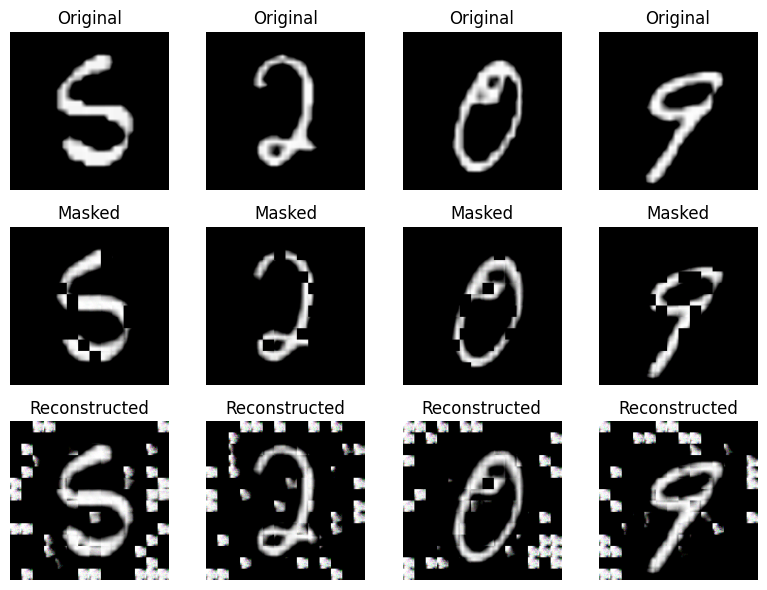

<All keys matched successfully>

In [10]:
import matplotlib.pyplot as plt

model.eval()
images, _ = next(iter(data_loader_train))
images = images[:4].to(device)

with torch.no_grad():
    loss, pred, mask = model(images, mask_ratio=args.mask_ratio)

recon_images = model.unpatchify(pred).cpu()
images = images.cpu()
mask = mask.unsqueeze(-1).repeat(1, 1, pred.shape[2])
mask_image = model.unpatchify(torch.mul(pred, mask)).cpu()

def show_images(original, masked, reconstructed):
    fig, axs = plt.subplots(3, len(original), figsize=(len(original)*2, 6))
    for i in range(len(original)):
        axs[0, i].imshow(original[i].permute(1, 2, 0), cmap='gray')
        axs[0, i].set_title("Original")
        axs[1, i].imshow(masked[i].permute(1, 2, 0), cmap='gray')
        axs[1, i].set_title("Masked")
        axs[2, i].imshow(reconstructed[i].permute(1, 2, 0), cmap='gray')
        axs[2, i].set_title("Reconstructed")
        for ax in axs[:, i]:
            ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images(images, mask_image, recon_images)

model.load_state_dict(torch.load("output/mae_epoch9.pth"))